In [41]:
import pandas as pd
import numpy as np

import scipy.stats as stats

import matplotlib.pyplot as plt
import seaborn as sns

In [21]:
df = pd.read_csv("../Titanic-Dataset.csv", usecols=['Age','Fare','Survived'])

In [22]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [23]:
df.isna().sum()

Survived      0
Age         177
Fare          0
dtype: int64

In [34]:
df.fillna({'Age': df['Age'].mean()}, inplace=True)

In [35]:
df.isna().sum()

Survived    0
Age         0
Fare        0
dtype: int64

In [36]:
X = df.iloc[:, 1:3]
y = df.iloc[:, 0]

In [37]:
from sklearn.model_selection import train_test_split

In [39]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

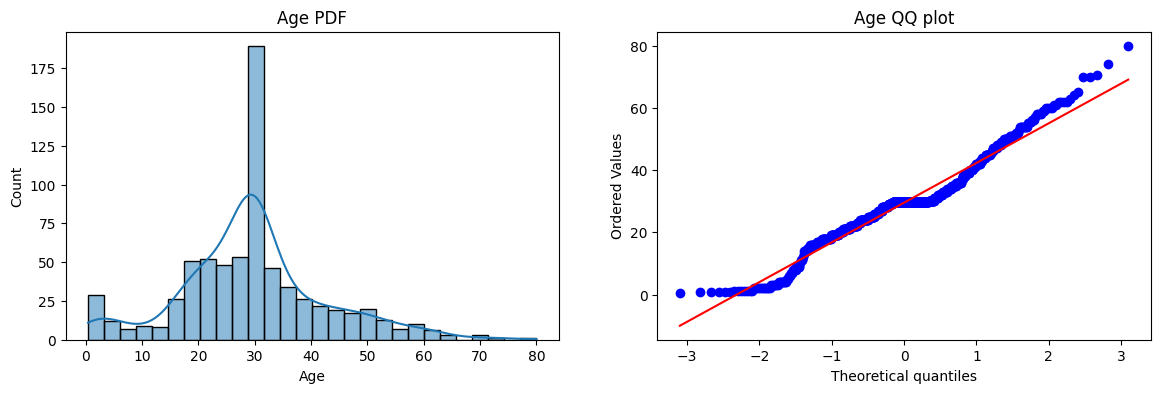

In [49]:
# plotting

plt.figure(figsize=(14,4))
plt.subplot(121)
sns.histplot(X_train['Age'], kde=True)
plt.title('Age PDF')

plt.subplot(122)
stats.probplot(X_train['Age'], dist='norm', plot=plt)
plt.title("Age QQ plot")

plt.show()

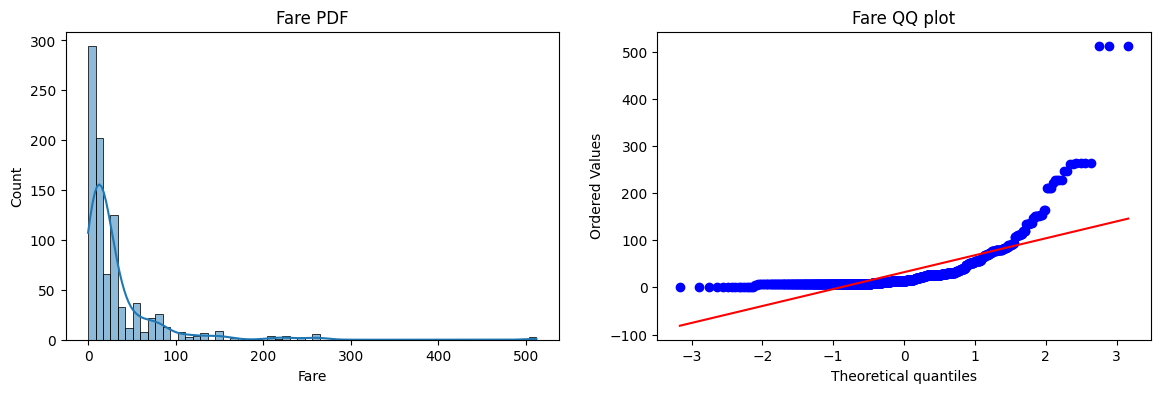

In [52]:
plt.figure(figsize=(14,4))

plt.subplot(121)
sns.histplot(df['Fare'], kde=True)
plt.title("Fare PDF")

plt.subplot(122)
stats.probplot(df['Fare'], dist='norm', plot=plt)
plt.title("Fare QQ plot")

plt.show()

## Classifier without any kind of Transformation

In [53]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

In [54]:
clf_lr = LogisticRegression()
clf_dt = DecisionTreeClassifier()

In [56]:
from sklearn.metrics import accuracy_score

In [62]:
def calc_accuracy_score(X_train, X_test, y_train, y_test):
    clf_lr.fit(X_train, y_train)
    clf_dt.fit(X_train, y_train)

    y_pred_lr = clf_lr.predict(X_test)
    y_pred_dt = clf_dt.predict(X_test)

    print("Accuracy Score of LR: ", accuracy_score(y_test, y_pred_lr))
    print("Accuracy Score of DT: ", accuracy_score(y_test, y_pred_dt))

In [63]:
calc_accuracy_score(X_train, X_test, y_train, y_test)

Accuracy Score of LR:  0.6480446927374302
Accuracy Score of DT:  0.659217877094972


## Classifier after using the Log Transform on both the columns

In [58]:
from sklearn.preprocessing import FunctionTransformer

In [59]:
trf = FunctionTransformer(func=np.log1p)

In [60]:
X_train_transformed = trf.fit_transform(X_train)
X_test_transformed = trf.transform(X_test)

In [64]:
calc_accuracy_score(X_train_transformed, X_test_transformed, y_train, y_test)

Accuracy Score of LR:  0.6815642458100558
Accuracy Score of DT:  0.6927374301675978


# Cross-Validating to confirm if it's actually improving

In [65]:
from sklearn.model_selection import cross_val_score

In [66]:
X_transformed = trf.transform(X)

print("LR: ", np.mean(cross_val_score(clf_lr, X_transformed, y, scoring="accuracy", cv=10)))
print("DT: ", np.mean(cross_val_score(clf_dt, X_transformed, y, scoring="accuracy", cv=10)))

LR:  0.678027465667915
DT:  0.6610861423220975


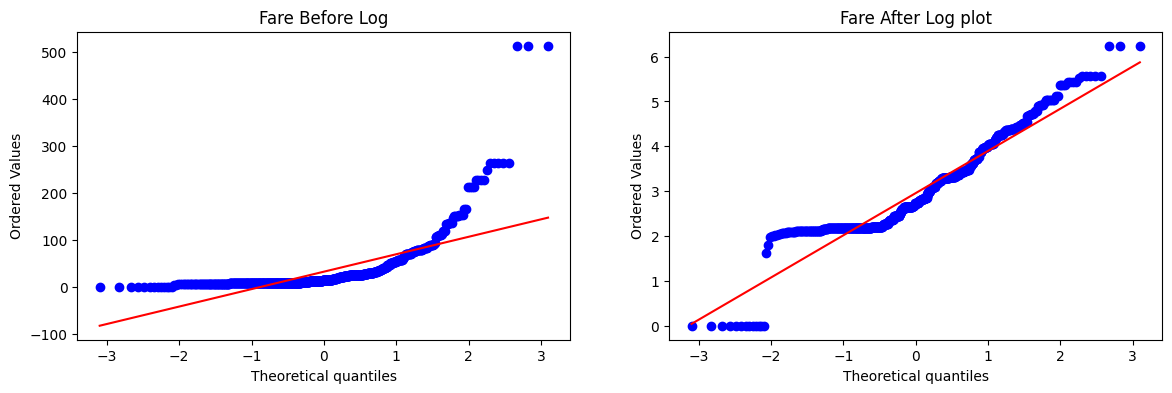

In [71]:
plt.figure(figsize=(14,4))

plt.subplot(121)
stats.probplot(X_train['Fare'], dist='norm', plot=plt)
plt.title('Fare Before Log')

plt.subplot(122)
stats.probplot(X_train_transformed['Fare'], dist='norm', plot=plt)
plt.title("Fare After Log plot")

plt.show()

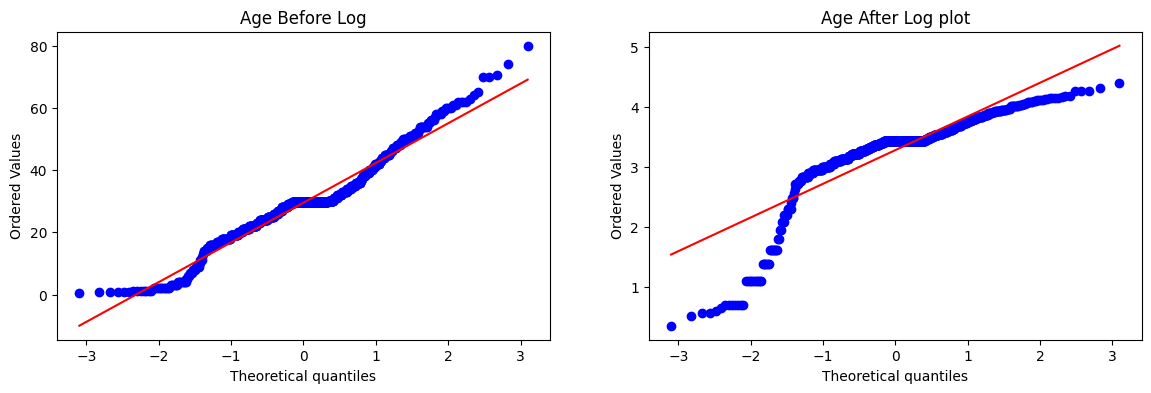

In [72]:
plt.figure(figsize=(14,4))

plt.subplot(121)
stats.probplot(X_train['Age'], dist='norm', plot=plt)
plt.title('Age Before Log')

plt.subplot(122)
stats.probplot(X_train_transformed['Age'], dist='norm', plot=plt)
plt.title("Age After Log plot")

plt.show()